In [12]:
# perform exploratory data analysis on Dataset of Dwelling Time xlsx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_excel('Dataset of Dwelling Time Process Fix.xlsx')
# perform exploratory data analysis
# check for missing values
df.isnull().sum()

# check for duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
# get column names, head, and statistical overview of data in df
print(f"The columns are {df.columns}")
print(f"The first 5 rows are {df.head()}")
print(f"The statistical overview of the data is {df.describe()}")


The columns are Index(['case_id', 'CTR_SIZE', 'CTR_TYPE', 'GROSS', 'YARD_BLOCK', 'YARD_SLOT',
       'JOB_DEL_DOCTYPE', 'activity', 'Start Timestamp', 'End Timestamp',
       'Duration', 'Role'],
      dtype='object')
The first 5 rows are                   case_id  CTR_SIZE CTR_TYPE  GROSS YARD_BLOCK  YARD_SLOT  \
0  AAAU9001220-2021-06-28      40.0      DRY    NaN        NaN        NaN   
1  AAAU9001220-2021-06-28       NaN      NaN    NaN        NaN        NaN   
2  AAAU9001220-2021-06-28       NaN      NaN   12.2          N       98.0   
3  AAAU9001220-2021-06-28       NaN      NaN    NaN        NaN        NaN   
4  AAAU9001220-2021-06-28       NaN      NaN    NaN        NaN        NaN   

  JOB_DEL_DOCTYPE             activity         Start Timestamp  \
0             NaN               BAPLIE 2021-06-27 10:50:12.791   
1             NaN           VESSEL_ATB 2021-06-28 18:35:04.800   
2             NaN            DISCHARGE 2021-06-28 20:51:27.491   
3             NaN                S

In [19]:
"""
    python clean_dwell_time.py --input raw_data.csv --output cleaned_dwell_time.csv
"""

import argparse
import pandas as pd
import numpy as np
from pathlib import Path


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--input",  default="raw_data.csv",         help="Path to raw CSV")
    p.add_argument("--output", default="cleaned_dwell_time.csv", help="Path for output CSV")
    return p.parse_args()

def load(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
    return df

def parse_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    for col in ["Start Timestamp", "End Timestamp"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


# make sure all container level attributes are filled
# CTR_SIZE, CTR_TYPE, GROSS, YARD_BLOCK, YARD_SLOT, JOB_DEL_DOCTYPE are only populated on certain event rows but should be with each case.
CONTAINER_ATTRS = ["CTR_SIZE", "CTR_TYPE", "GROSS",
                   "YARD_BLOCK", "YARD_SLOT", "JOB_DEL_DOCTYPE"]

def ffill_attrs(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["case_id", "Start Timestamp"])
    for col in CONTAINER_ATTRS:
        df[col] = df.groupby("case_id")[col].transform(
            lambda s: s.ffill().bfill()
        )
    return df


# summarize per container instead of entire event log
# container lands in yard
ARRIVAL_ACTIVITY   = "DISCHARGE"    
# container leaves terminal
DEPARTURE_ACTIVITY = "GATE_OUT"     

# important activities in terminal
FLAG_ACTIVITIES = {
    "HAS_QUARANTINE_FLAG": "flag_quarantine",
    "CUSTOMS_HOLD":        "flag_customs",
    "DAMAGE_NOTED":        "flag_damage",
}

def build_container_features(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for case_id, grp in df.groupby("case_id"):
        grp = grp.sort_values("Start Timestamp")

        row = {"case_id": case_id}
        for col in CONTAINER_ATTRS:
            row[col] = grp[col].dropna().iloc[0] if grp[col].notna().any() else np.nan

        discharge_rows = grp[grp["activity"] == ARRIVAL_ACTIVITY]
        gate_out_rows  = grp[grp["activity"] == DEPARTURE_ACTIVITY]

        # if you're missing one of these important data points you cant find the dwell time
        if discharge_rows.empty or gate_out_rows.empty:
            row["discharge_time"] = np.nan
            row["gate_out_time"]  = np.nan
            row["dwell_hours"]    = np.nan
        else:
            t_in  = discharge_rows["Start Timestamp"].min()
            t_out = gate_out_rows["Start Timestamp"].max()
            dwell = (t_out - t_in).total_seconds() / 3600
            row["discharge_time"] = t_in
            row["gate_out_time"]  = t_out
            row["dwell_hours"]    = dwell if dwell > 0 else np.nan

        if pd.notna(row.get("discharge_time")):
            ts = row["discharge_time"]
            row["discharge_hour"]     = ts.hour
            row["discharge_dayofweek"] = ts.dayofweek   # 0=Mon
            row["discharge_month"]    = ts.month
            row["discharge_is_weekend"] = int(ts.dayofweek >= 5)

        acts = set(grp["activity"].dropna().unique())
        for act, feat in FLAG_ACTIVITIES.items():
            row[feat] = int(act in acts)

        row["n_events"]        = len(grp)
        row["n_unique_roles"]  = grp["Role"].nunique()
        row["n_unique_activities"] = grp["activity"].nunique()

        # time vessel berth arrival / ATB --> discharge
        atb_rows = grp[grp["activity"] == "VESSEL_ATB"]
        if not atb_rows.empty and pd.notna(row.get("discharge_time")):
            atb_time = atb_rows["Start Timestamp"].min()
            row["hours_atb_to_discharge"] = (
                (row["discharge_time"] - atb_time).total_seconds() / 3600
            )
        else:
            row["hours_atb_to_discharge"] = np.nan

        records.append(row)

    result = pd.DataFrame(records)
    print(f"Built {len(result):,} container-level records")
    return result


# encode types
def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    # numerical encoding
    df["CTR_SIZE"] = pd.to_numeric(df["CTR_SIZE"], errors="coerce")
    df["GROSS"]    = pd.to_numeric(df["GROSS"],    errors="coerce")
    df["YARD_SLOT"]= pd.to_numeric(df["YARD_SLOT"],errors="coerce")

    # one-hot encoding
    for col in ["CTR_TYPE", "JOB_DEL_DOCTYPE"]:
        if col in df.columns:
            dummies = pd.get_dummies(df[col], prefix=col, dummy_na=False)
            df = pd.concat([df.drop(columns=[col]), dummies], axis=1)

    # encode yard block labels
    if "YARD_BLOCK" in df.columns:
        df["YARD_BLOCK_enc"] = pd.Categorical(df["YARD_BLOCK"]).codes
        df["YARD_BLOCK_enc"] = df["YARD_BLOCK_enc"].replace(-1, np.nan)
        df = df.drop(columns=["YARD_BLOCK"])

    return df


# filter and cap outliers
def filter_outliers(df: pd.DataFrame,
                    min_hours: float = 0.5,
                    max_hours: float = 30 * 24) -> pd.DataFrame:
   # get rid of dwell times above 30 days
   # get rid of dwell times below 30 minutes
   # keep rows with NaN dwell_hours (maybe could help later?)
    mask = df["dwell_hours"].isna() | (
        (df["dwell_hours"] >= min_hours) &
        (df["dwell_hours"] <= max_hours)
    )
    n_removed = (~mask).sum()
    print(f"Outlier filter: removed {n_removed} rows "
          f"(dwell < {min_hours}h or > {max_hours}h)")
    return df[mask].copy()


# find/replace/report/deal with missing values

def handle_missing(df: pd.DataFrame) -> pd.DataFrame:
    # show
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss):
        print("\nMissing values after cleaning:")
        print(miss.to_string())

    # put in median instead (could do mean/min/max/0 instead???)
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    return df


# drop cols that are going to mess with the model
DROP_COLS = ["discharge_time", "gate_out_time"]
def drop_leakage(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    return df.drop(columns=cols_to_drop)



In [24]:
df = pd.read_excel('Dataset of Dwelling Time Process Fix.xlsx')
df = parse_timestamps(df)
df = ffill_attrs(df)
df = build_container_features(df)
df = encode_categoricals(df)
df = filter_outliers(df)
df = handle_missing(df)
df = drop_leakage(df)

    # Final summary
labeled = df["dwell_hours"].notna().sum()
print(f"\nFinal dataset: {len(df):,} containers "
          f"({labeled:,} with dwell_hours label, "
          f"{len(df)-labeled:,} unlabeled)")
print(f"Features: {[c for c in df.columns if c not in ['case_id','dwell_hours']]}")

out = "cleaned_dwell_time.csv"
# out = Path(args.output)
df.to_csv(out, index=False)
print(f"\nSaved → {out}")



Built 95,648 container-level records
Outlier filter: removed 0 rows (dwell < 0.5h or > 720h)

Missing values after cleaning:
discharge_time            95648
gate_out_time             95648
dwell_hours               95648
hours_atb_to_discharge    95648
YARD_SLOT                   242
YARD_BLOCK_enc               24

Final dataset: 95,648 containers (0 with dwell_hours label, 95,648 unlabeled)
Features: ['CTR_SIZE', 'GROSS', 'YARD_SLOT', 'flag_quarantine', 'flag_customs', 'flag_damage', 'n_events', 'n_unique_roles', 'n_unique_activities', 'hours_atb_to_discharge', 'CTR_TYPE_DRY', 'CTR_TYPE_FLT', 'CTR_TYPE_O/T', 'CTR_TYPE_OVD', 'CTR_TYPE_RFR', 'CTR_TYPE_TNK', 'JOB_DEL_DOCTYPE_BC23', 'JOB_DEL_DOCTYPE_BCF26', 'JOB_DEL_DOCTYPE_LAIN2', 'JOB_DEL_DOCTYPE_LELANG', 'JOB_DEL_DOCTYPE_NNMITA', 'JOB_DEL_DOCTYPE_PLP', 'JOB_DEL_DOCTYPE_SPPB', 'JOB_DEL_DOCTYPE_TMBLU', 'YARD_BLOCK_enc']

Saved → cleaned_dwell_time.csv


In [41]:
# import argparse
# import warnings
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import seaborn as sns

# # warnings.filterwarnings("ignore")

# # make it pretty
# sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
# PALETTE = sns.color_palette("muted")
# FIG_DPI = 150

# def savefig(fig, outdir, name: str):
#     path = Path(outdir) / f"{name}.png"
#     fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
#     plt.close(fig)
#     print(f"  Saved {path}")


# # plot
# def plot_dwell_distribution(df, outdir):
#     # dwell times
#     dwell = df["dwell_hours"].dropna()
#     fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#     # ilnear
#     axes[0].hist(dwell, bins=60, color=PALETTE[0], edgecolor="white", linewidth=0.4)
#     axes[0].set_xlabel("Dwell Time (hours)")
#     axes[0].set_ylabel("Count")
#     axes[0].set_title("Dwell Time Distribution (linear)")
#     axes[0].axvline(dwell.median(), color="crimson", lw=1.5,
#                     linestyle="--", label=f"Median {dwell.median():.1f}h")
#     axes[0].legend()

#     # log-transformed
#     log_dwell = np.log1p(dwell)
#     axes[1].hist(log_dwell, bins=60, color=PALETTE[1], edgecolor="white", linewidth=0.4)
#     axes[1].set_xlabel("log(1 + Dwell Hours)")
#     axes[1].set_title("Dwell Time Distribution (log scale)")
#     axes[1].set_ylabel("Count")

#     fig.suptitle("Target Variable: Container Dwell Time", fontweight="bold", y=1.01)
#     fig.tight_layout()
#     savefig(fig, outdir, "01_dwell_distribution")


# def plot_dwell_by_ctr_type(df, outdir):
#    # dwell time by container type
#     ctr_type_cols = [c for c in df.columns if c.startswith("CTR_TYPE_")]
#     if not ctr_type_cols:
#         if "CTR_TYPE" in df.columns:
#             fig, ax = plt.subplots(figsize=(9, 5))
#             order = df.groupby("CTR_TYPE")["dwell_hours"].median().sort_values().index.tolist()
#             for i, cat in enumerate(order):
#                 vals = df[df["CTR_TYPE"] == cat]["dwell_hours"].dropna()
#                 ax.boxplot(vals, positions=[i], widths=0.6, patch_artist=True,
#                            boxprops=dict(facecolor=PALETTE[i % len(PALETTE)]),
#                            medianprops=dict(color="black"), showfliers=False)
#             ax.set_xticks(range(len(order)))
#             ax.set_xticklabels(order)
#             ax.set_title("Dwell Time by Container Type")
#             ax.set_xlabel("Container Type")
#             ax.set_ylabel("Dwell Time (hours)")
#             fig.tight_layout()
#             savefig(fig, outdir, "02_dwell_by_ctr_type")
#         return

#     # get type label from encoding 
#     df2 = df.copy()
#     df2["CTR_TYPE_label"] = (
#         df2[ctr_type_cols]
#         .idxmax(axis=1)
#         .str.replace("CTR_TYPE_", "", regex=False)
#     )
#     order = df2.groupby("CTR_TYPE_label")["dwell_hours"].median().sort_values().index.tolist()
#     fig, ax = plt.subplots(figsize=(9, 5))
#     for i, cat in enumerate(order):
#         vals = df2[df2["CTR_TYPE_label"] == cat]["dwell_hours"].dropna()
#         ax.boxplot(vals, positions=[i], widths=0.6, patch_artist=True,
#                    boxprops=dict(facecolor=PALETTE[i % len(PALETTE)]),
#                    medianprops=dict(color="black"), showfliers=False)
#     ax.set_xticks(range(len(order)))
#     ax.set_xticklabels(order)
#     ax.set_title("Dwell Time by Container Type")
#     ax.set_xlabel("Container Type")
#     ax.set_ylabel("Dwell Time (hours)")
#     fig.tight_layout()
#     savefig(fig, outdir, "02_dwell_by_ctr_type")

# # dwell time by container size TEUs
# def plot_dwell_by_size(df, outdir):
#     if "CTR_SIZE" not in df.columns:
#         return
#     df2 = df.copy()
#     df2["CTR_SIZE_cat"] = df2["CTR_SIZE"].apply(
#         lambda x: "20ft" if x == 20 else ("40ft" if x == 40 else "Other/Unknown")
#     )
#     fig, ax = plt.subplots(figsize=(8, 5))
#     sns.violinplot(data=df2, x="CTR_SIZE_cat", y="dwell_hours",
#                    hue="CTR_SIZE_cat", palette="muted", legend=False, inner="quartile", ax=ax)
#     ax.set_title("Dwell Time by Container Size")
#     ax.set_xlabel("Container Size")
#     ax.set_ylabel("Dwell Time (hours)")
#     fig.tight_layout()
#     savefig(fig, outdir, "03_dwell_by_size")

# # heatmap by hour of discharge/week day
# def plot_temporal_patterns(df, outdir):
#     needed = ["discharge_hour", "discharge_dayofweek", "dwell_hours"]
#     if not all(c in df.columns for c in needed):
#         return

#     pivot = (
#         df.groupby(["discharge_dayofweek", "discharge_hour"])["dwell_hours"]
#         .median()
#         .unstack(fill_value=np.nan)
#     )
#     day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
#     pivot.index = [day_labels[i] for i in pivot.index if i < 7]

#     fig, ax = plt.subplots(figsize=(14, 4))
#     sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3,
#                 cbar_kws={"label": "Median Dwell (hours)"}, ax=ax)
#     ax.set_title("Median Dwell Time by Discharge Hour and Day of Week")
#     ax.set_xlabel("Hour of Day")
#     ax.set_ylabel("Day of Week")
#     fig.tight_layout()
#     savefig(fig, outdir, "04_temporal_heatmap")

# # line chart of dwell time by month
# def plot_monthly_trend(df, outdir):
#     if "discharge_month" not in df.columns:
#         return

#     monthly = df.groupby("discharge_month")["dwell_hours"].agg(
#         median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
#     )
#     fig, ax = plt.subplots(figsize=(9, 4))
#     ax.plot(monthly.index, monthly["median"], marker="o", color=PALETTE[0], label="Median")
#     ax.fill_between(monthly.index, monthly["q25"], monthly["q75"],
#                     alpha=0.25, color=PALETTE[0], label="IQR (25–75%)")
#     ax.set_xticks(range(1, 13))
#     ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
#                          "Jul","Aug","Sep","Oct","Nov","Dec"])
#     ax.set_xlabel("Month of Discharge")
#     ax.set_ylabel("Dwell Time (hours)")
#     ax.set_title("Monthly Trend in Dwell Time")
#     ax.legend()
#     fig.tight_layout()
#     savefig(fig, outdir, "05_monthly_trend")

# # bar chart of mean dwell time for containers with/without operational flags
# def plot_flag_impact(df, outdir):
#     flag_cols = [c for c in df.columns if c.startswith("flag_")]
#     if not flag_cols or "dwell_hours" not in df.columns:
#         return

#     results = []
#     for flag in flag_cols:
#         for val, label in [(0, "No"), (1, "Yes")]:
#             subset = df[df[flag] == val]["dwell_hours"].dropna()
#             if len(subset):
#                 results.append({
#                     "flag": flag.replace("flag_", "").replace("_", " ").title(),
#                     "flagged": label,
#                     "mean_dwell": subset.mean(),
#                     "sem": subset.sem(),
#                 })

#     res_df = pd.DataFrame(results)
#     flags_unique = res_df["flag"].unique()
#     fig, ax = plt.subplots(figsize=(9, 5))
#     x = np.arange(len(flags_unique))
#     width = 0.35

#     for i, (flagged, color) in enumerate([("No", PALETTE[0]), ("Yes", PALETTE[3])]):
#         subset = res_df[res_df["flagged"] == flagged].set_index("flag").reindex(flags_unique)
#         ax.bar(x + i * width - width / 2,
#                subset["mean_dwell"].fillna(0).values,
#                width, label=flagged, color=color, alpha=0.85,
#                yerr=subset["sem"].fillna(0).values, capsize=4)

#     ax.set_xticks(x)
#     ax.set_xticklabels(flags_unique, rotation=15, ha="right")
#     ax.set_ylabel("Mean Dwell Time (hours)")
#     ax.set_title("Impact of Operational Flags on Dwell Time")
#     ax.legend(title="Flag Active?")
#     fig.tight_layout()
#     savefig(fig, outdir, "06_flag_impact")

# # scatter of gross weight vs dwell time
# def plot_gross_vs_dwell(df, outdir):
#     if "GROSS" not in df.columns or "dwell_hours" not in df.columns:
#         return
#     sub = df[["GROSS", "dwell_hours"]].dropna()
#     sub = sub[(sub["GROSS"] > 0) & (sub["dwell_hours"] > 0)]

#     fig, ax = plt.subplots(figsize=(8, 5))
#     ax.scatter(sub["GROSS"], sub["dwell_hours"],
#                alpha=0.25, s=12, color=PALETTE[2], edgecolors="none")
#     # Trend line
#     z = np.polyfit(sub["GROSS"], sub["dwell_hours"], 1)
#     xfit = np.linspace(sub["GROSS"].min(), sub["GROSS"].max(), 200)
#     ax.plot(xfit, np.poly1d(z)(xfit), color="crimson", lw=1.5, label="Linear trend")
#     ax.set_xlabel("Gross Weight (tonnes)")
#     ax.set_ylabel("Dwell Time (hours)")
#     ax.set_title("Gross Weight vs. Dwell Time")
#     ax.legend()
#     fig.tight_layout()
#     savefig(fig, outdir, "07_gross_vs_dwell")


# # heatmap of correlation matrix
# def plot_correlation_matrix(df, outdir):
#     exclude = ["case_id"]
#     num_df = df.drop(columns=[c for c in exclude if c in df.columns], errors="ignore")
#     num_df = num_df.select_dtypes(include=[np.number])
#     corr = num_df.corr()

#     fig, ax = plt.subplots(figsize=(max(8, len(corr) * 0.55),
#                                     max(6, len(corr) * 0.5)))
#     mask = np.triu(np.ones_like(corr, dtype=bool))
#     sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
#                 cmap="coolwarm", center=0, linewidths=0.4,
#                 annot_kws={"size": 8}, ax=ax,
#                 cbar_kws={"shrink": 0.7})
#     ax.set_title("Feature Correlation Matrix", fontweight="bold")
#     fig.tight_layout()
#     savefig(fig, outdir, "08_correlation_matrix")


# # missing values bar chart 
# def plot_missing_values(df, outdir):
#     miss = df.isnull().sum().sort_values(ascending=False)
#     miss = miss[miss > 0]
#     if miss.empty:
#         print("  No missing values found — skipping missing values plot.")
#         return

#     fig, ax = plt.subplots(figsize=(10, max(4, len(miss) * 0.4)))
#     miss.plot(kind="barh", ax=ax, color=PALETTE[4])
#     ax.set_xlabel("Missing Count")
#     ax.set_title("Missing Values by Column")
#     fig.tight_layout()
#     savefig(fig, outdir, "09_missing_values")

# # more events = longer dwell?
# def plot_n_events_vs_dwell(df, outdir):
#     if "n_events" not in df.columns:
#         return
#     fig, ax = plt.subplots(figsize=(8, 5))
#     grouped = df.groupby("n_events")["dwell_hours"].median().reset_index()
#     ax.bar(grouped["n_events"], grouped["dwell_hours"],
#            color=PALETTE[0], alpha=0.8, edgecolor="white", linewidth=0.4)
#     ax.set_xlabel("Number of Events per Container")
#     ax.set_ylabel("Median Dwell Time (hours)")
#     ax.set_title("Process Complexity vs. Dwell Time")
#     ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
#     fig.tight_layout()
#     savefig(fig, outdir, "10_n_events_vs_dwell")

Shape: (95648, 27)
                  case_id  CTR_SIZE  GROSS  YARD_SLOT  dwell_hours  \
0  AAAU9001220-2021-06-28      40.0   12.2       98.0          NaN   
1  AAMU2609009-2021-09-26      20.0   25.9       51.0          NaN   
2  AAMU2609164-2021-09-07      20.0   25.8       11.0          NaN   
3  AAMU4000372-2021-09-07      40.0   28.7       30.0          NaN   
4  AAMU4000705-2021-09-07      40.0   25.9        2.0          NaN   

   flag_quarantine  flag_customs  flag_damage  n_events  n_unique_roles  ...  \
0                1             0            0        12               7  ...   
1                0             0            0         9               6  ...   
2                0             0            0         9               6  ...   
3                1             0            0        12               7  ...   
4                1             0            0        12               7  ...   

   CTR_TYPE_TNK  JOB_DEL_DOCTYPE_BC23  JOB_DEL_DOCTYPE_BCF26  \
0         False

FileNotFoundError: [Errno 2] No such file or directory: 'plots/CTR_TYPE_O/T_distribution.png'

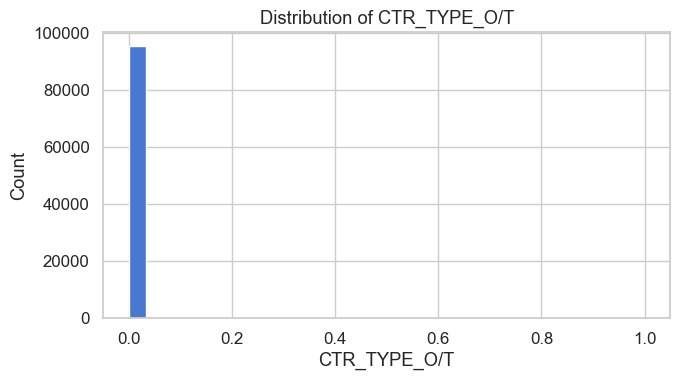

In [42]:
import os
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "data/cleaned_dwell_time.csv" 
OUT_DIR = "plots"

os.makedirs(OUT_DIR, exist_ok=True)
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print(df.head())
print(df.info())

bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)
numeric_cols = df.select_dtypes(include=["number"]).columns

missing = df.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
missing[missing > 0].plot(kind="bar")
plt.ylabel("Fraction missing")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/missing_values.png")
plt.close()

# 2. Dwell hours distribution
if "dwell_hours" in df.columns:
    plt.figure(figsize=(8, 5))
    df["dwell_hours"].dropna().hist(bins=40)
    plt.xlabel("Dwell Hours")
    plt.ylabel("Count")
    plt.title("Distribution of Container Dwell Hours")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/dwell_hours_distribution.png")
    plt.close()

# -----------------------------
# 3. Numeric feature distributions
# -----------------------------
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    df[col].dropna().hist(bins=30)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{col}_distribution.png")
    plt.close()

# -----------------------------
# 4. Correlation heatmap
# -----------------------------
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/correlation_heatmap.png")
plt.close()

# -----------------------------
# 5. Flags vs dwell time
# -----------------------------
flag_cols = [c for c in df.columns if c.startswith("flag_")]

for col in flag_cols:
    if "dwell_hours" in df.columns:
        plot_df = df[[col, "dwell_hours"]].dropna()

        plt.figure(figsize=(6, 4))
        plot_df.boxplot(column="dwell_hours", by=col)
        plt.title(f"Dwell Hours by {col}")
        plt.suptitle("")
        plt.xlabel(col)
        plt.ylabel("Dwell Hours")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/dwell_by_{col}.png")
        plt.close()

# -----------------------------
# 6. Container type counts
# -----------------------------
ctr_type_cols = [c for c in df.columns if c.startswith("CTR_TYPE_")]

if ctr_type_cols:
    counts = df[ctr_type_cols].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title("Container Type Counts")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/container_type_counts.png")
    plt.close()

# -----------------------------
# 7. Document type counts
# -----------------------------
doc_cols = [c for c in df.columns if c.startswith("JOB_DEL_DOCTYPE_")]

if doc_cols:
    counts = df[doc_cols].sum().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title("Job Delivery Document Type Counts")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/doctype_counts.png")
    plt.close()

# -----------------------------
# 8. Scatter plots against dwell_hours
# -----------------------------
important_features = [
    "CTR_SIZE",
    "GROSS",
    "YARD_SLOT",
    "n_events",
    "n_unique_roles",
    "n_unique_activities",
    "hours_atb_to_discharge",
    "YARD_BLOCK_enc"
]

for col in important_features:
    if col in df.columns and "dwell_hours" in df.columns:
        plot_df = df[[col, "dwell_hours"]].dropna()

        plt.figure(figsize=(6, 4))
        plt.scatter(plot_df[col], plot_df["dwell_hours"], alpha=0.5)
        plt.xlabel(col)
        plt.ylabel("Dwell Hours")
        plt.title(f"{col} vs Dwell Hours")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/{col}_vs_dwell_hours.png")
        plt.close()

print(f"Done. Figures saved in: {OUT_DIR}/")

In [32]:
!pwd

/Users/kellyg/eurogate-twin-1


In [44]:
# print(df["dwell_hours"].count())
# print(df["dwell_hours"].isna().mean())

In [51]:
import pandas as pd
import numpy as np

RAW_PATH = "data/Dataset of Dwelling Time Process Fix.xlsx"
OUT_PATH = "data/container_ml_ready.csv"

df = pd.read_excel(RAW_PATH)

# -----------------------------
# Column names for your dataset
# -----------------------------
CASE_COL = "case_id"
ACT_COL = "activity"
START_COL = "Start Timestamp"
END_COL = "End Timestamp"

# -----------------------------
# Parse timestamps
# -----------------------------
df[START_COL] = pd.to_datetime(df[START_COL], errors="coerce")
df[END_COL] = pd.to_datetime(df[END_COL], errors="coerce")

df = df.dropna(subset=[CASE_COL, ACT_COL, START_COL])

df[ACT_COL] = df[ACT_COL].astype(str).str.strip().str.upper()

# -----------------------------
# Sort events
# -----------------------------
df = df.sort_values([CASE_COL, START_COL])

# -----------------------------
# Debug: inspect activities
# -----------------------------
print("\nTop activities:")
print(df[ACT_COL].value_counts().head(50))

# -----------------------------
# Dwell time target
# -----------------------------
# Start = when container is discharged from vessel
discharge_time = (
    df[df[ACT_COL].eq("DISCHARGE")]
    .groupby(CASE_COL)[END_COL]
    .min()
    .rename("discharge_time")
)

# End = last known event timestamp for that container
last_time = (
    df.groupby(CASE_COL)[END_COL]
    .max()
    .rename("last_event_time")
)

target = pd.concat([discharge_time, last_time], axis=1).reset_index()

target["dwell_hours"] = (
    target["last_event_time"] - target["discharge_time"]
).dt.total_seconds() / 3600

target = target[
    target["dwell_hours"].notna()
    & (target["dwell_hours"] > 0)
]

print("\nDwell target coverage:")
print("Containers with DISCHARGE:", discharge_time.shape[0])
print("Containers with valid dwell_hours:", target.shape[0])
print(target["dwell_hours"].describe())

# -----------------------------
# Static container attributes
# -----------------------------
static_cols = [
    "CTR_SIZE",
    "CTR_TYPE",
    "GROSS",
    "YARD_BLOCK",
    "YARD_SLOT",
    "JOB_DEL_DOCTYPE",
]

static_features = (
    df.groupby(CASE_COL)[static_cols]
    .agg(lambda x: x.dropna().iloc[0] if x.dropna().shape[0] > 0 else np.nan)
    .reset_index()
)

# -----------------------------
# Event-based features
# IMPORTANT:
# Use only events up to DISCHARGE if predicting at discharge time.
# Otherwise you leak future information.
# -----------------------------
df_with_discharge = df.merge(
    discharge_time.reset_index(),
    on=CASE_COL,
    how="left"
)

pre_discharge = df_with_discharge[
    df_with_discharge[START_COL] <= df_with_discharge["discharge_time"]
].copy()

event_features = pre_discharge.groupby(CASE_COL).agg(
    n_events=(ACT_COL, "count"),
    n_unique_activities=(ACT_COL, "nunique"),
    n_unique_roles=("Role", "nunique"),
    hours_atb_to_discharge=(
        START_COL,
        lambda x: np.nan
    )
).reset_index()

# Compute VESSEL_ATB to DISCHARGE timing
vessel_atb = (
    df[df[ACT_COL].eq("VESSEL_ATB")]
    .groupby(CASE_COL)[START_COL]
    .min()
    .rename("vessel_atb_time")
)

event_features = event_features.merge(
    discharge_time.reset_index(),
    on=CASE_COL,
    how="left"
).merge(
    vessel_atb.reset_index(),
    on=CASE_COL,
    how="left"
)

event_features["hours_atb_to_discharge"] = (
    event_features["discharge_time"] - event_features["vessel_atb_time"]
).dt.total_seconds() / 3600

event_features = event_features.drop(
    columns=["discharge_time", "vessel_atb_time"]
)

# -----------------------------
# Flags
# -----------------------------
flag_features = df.groupby(CASE_COL).agg(
    flag_quarantine=(ACT_COL, lambda x: int((x == "HAS_QUARANTINE_FLAG").any())),
    flag_customs=(ACT_COL, lambda x: int((x == "HAS_CUSTOMS_FLAG").any())),
    flag_damage=(ACT_COL, lambda x: int((x == "HAS_DAMAGE_FLAG").any())),
).reset_index()

# -----------------------------
# Merge all features + target
# -----------------------------
ml_df = (
    static_features
    .merge(event_features, on=CASE_COL, how="left")
    .merge(flag_features, on=CASE_COL, how="left")
    .merge(target[[CASE_COL, "dwell_hours"]], on=CASE_COL, how="inner")
)

# -----------------------------
# Encode categoricals
# -----------------------------
ml_df = pd.get_dummies(
    ml_df,
    columns=["CTR_TYPE", "JOB_DEL_DOCTYPE"],
    dummy_na=False
)

# Yard block as category code
ml_df["YARD_BLOCK_enc"] = ml_df["YARD_BLOCK"].astype("category").cat.codes
ml_df = ml_df.drop(columns=["YARD_BLOCK"])

# -----------------------------
# Final cleanup
# -----------------------------
ml_df = ml_df.replace([np.inf, -np.inf], np.nan)

print("\nFinal ML dataframe:")
print(ml_df.shape)
print("Missing dwell_hours:", ml_df["dwell_hours"].isna().sum())
print("Dwell coverage:", ml_df["dwell_hours"].notna().mean())

print("\nMissing values:")
print(ml_df.isna().mean().sort_values(ascending=False).head(20))

ml_df.to_csv(OUT_PATH, index=False)
print(f"\nSaved to {OUT_PATH}")


Top activities:
activity
CUSTOMS_DEL                   95648
DISCHARGE                     95648
VESSEL_ATB                    95648
TRUCK_OUT                     95647
TRUCK_IN                      95647
BAPLIE                        95644
STACK                         95624
UNSTACK_TO_TRUCK              95536
JOB_DEL                       95147
QUARANTINE_RELEASE            26940
HAS_QUARANTINE_FLAG           26940
FIRST_STACK_QUARANTINE_BLK    13593
SP_RED_FLAG_PIB                5155
FIRST_STACK_BEHANDLE           4032
FIRST_JOB_CUSTOMS_BEHANDLE     3924
LAST_COMPLETE_BEHANDLE         3924
STACK_MAIN_YARD                3844
STACK_TRK_BF_MAIN_YARD         2951
JOB_PLP                         505
BEHANDLE_QUARANTINE_JOB          18
Name: count, dtype: int64

Dwell target coverage:
Containers with DISCHARGE: 95648
Containers with valid dwell_hours: 95648
count    95648.000000
mean        80.152398
std         94.318364
min          0.187500
25%         26.120486
50%         53.50000

In [53]:
# visualize_dwell_ml_data.py

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH = "data/container_ml_ready.csv"
OUT_DIR = "plots"

os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# Convert bool columns
for col in df.columns:
    if df[col].dtype == "bool":
        df[col] = df[col].astype(int)
    elif df[col].dropna().isin(["True", "False", True, False]).all():
        df[col] = df[col].map({"True": 1, "False": 0, True: 1, False: 0})

print("Shape:", df.shape)
print(df.head())
print("\nMissing values:")
print(df.isna().mean().sort_values(ascending=False).head(20))

# -----------------------------
# 1. Target distribution
# -----------------------------
plt.figure(figsize=(8, 5))
df["dwell_hours"].hist(bins=50)
plt.xlabel("Dwell Hours")
plt.ylabel("Count")
plt.title("Distribution of Dwell Time")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/dwell_hours_distribution.png")
plt.close()

plt.figure(figsize=(8, 5))
np.log1p(df["dwell_hours"]).hist(bins=50)
plt.xlabel("log(1 + Dwell Hours)")
plt.ylabel("Count")
plt.title("Log-Transformed Dwell Time")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/log_dwell_hours_distribution.png")
plt.close()

# -----------------------------
# 2. Missing values
# -----------------------------
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(10, 5))
    missing.plot(kind="bar")
    plt.ylabel("Fraction Missing")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/missing_values.png")
    plt.close()

# -----------------------------
# 3. Numeric feature histograms
# -----------------------------
numeric_cols = [
    "CTR_SIZE",
    "GROSS",
    "YARD_SLOT",
    "n_events",
    "n_unique_activities",
    "n_unique_roles",
    "hours_atb_to_discharge",
    "YARD_BLOCK_enc",
]

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        df[col].dropna().hist(bins=40)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/{col}_distribution.png")
        plt.close()

# -----------------------------
# 4. Feature vs dwell_hours scatterplots
# -----------------------------
for col in numeric_cols:
    if col in df.columns:
        plot_df = df[[col, "dwell_hours"]].dropna()

        plt.figure(figsize=(7, 4))
        plt.scatter(plot_df[col], plot_df["dwell_hours"], alpha=0.35)
        plt.xlabel(col)
        plt.ylabel("Dwell Hours")
        plt.title(f"{col} vs Dwell Hours")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/{col}_vs_dwell_hours.png")
        plt.close()

        plt.figure(figsize=(7, 4))
        plt.scatter(plot_df[col], np.log1p(plot_df["dwell_hours"]), alpha=0.35)
        plt.xlabel(col)
        plt.ylabel("log(1 + Dwell Hours)")
        plt.title(f"{col} vs Log Dwell Hours")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/{col}_vs_log_dwell_hours.png")
        plt.close()

# -----------------------------
# 5. Flag plots
# -----------------------------
flag_cols = ["flag_quarantine", "flag_customs", "flag_damage"]

for col in flag_cols:
    if col in df.columns:
        counts = df[col].value_counts().sort_index()

        plt.figure(figsize=(5, 4))
        counts.plot(kind="bar")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Counts of {col}")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/{col}_counts.png")
        plt.close()

        plt.figure(figsize=(6, 4))
        df.boxplot(column="dwell_hours", by=col)
        plt.title(f"Dwell Hours by {col}")
        plt.suptitle("")
        plt.xlabel(col)
        plt.ylabel("Dwell Hours")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/dwell_by_{col}.png")
        plt.close()

# -----------------------------
# 6. Container type percentages
# -----------------------------
ctr_type_cols = [c for c in df.columns if c.startswith("CTR_TYPE_")]

if ctr_type_cols:
    counts = df[ctr_type_cols].sum().sort_values(ascending=False)
    percents = counts / len(df) * 100

    plt.figure(figsize=(8, 5))
    percents.plot(kind="bar")
    plt.ylabel("Percent of Records")
    plt.title("Container Type Percentages")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/container_type_percentages.png")
    plt.close()

    # Average dwell by container type
    avg_dwell = {}
    for col in ctr_type_cols:
        avg_dwell[col.replace("CTR_TYPE_", "")] = df.loc[df[col] == 1, "dwell_hours"].mean()

    avg_dwell = pd.Series(avg_dwell).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    avg_dwell.plot(kind="bar")
    plt.ylabel("Average Dwell Hours")
    plt.title("Average Dwell Time by Container Type")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/avg_dwell_by_container_type.png")
    plt.close()

# -----------------------------
# 7. Document type percentages
# -----------------------------
doc_cols = [c for c in df.columns if c.startswith("JOB_DEL_DOCTYPE_")]

if doc_cols:
    counts = df[doc_cols].sum().sort_values(ascending=False)
    percents = counts / len(df) * 100

    plt.figure(figsize=(10, 5))
    percents.plot(kind="bar")
    plt.ylabel("Percent of Records")
    plt.title("Document Type Percentages")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/document_type_percentages.png")
    plt.close()

    avg_dwell = {}
    for col in doc_cols:
        avg_dwell[col.replace("JOB_DEL_DOCTYPE_", "")] = df.loc[df[col] == 1, "dwell_hours"].mean()

    avg_dwell = pd.Series(avg_dwell).sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    avg_dwell.plot(kind="bar")
    plt.ylabel("Average Dwell Hours")
    plt.title("Average Dwell Time by Document Type")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/avg_dwell_by_document_type.png")
    plt.close()

# -----------------------------
# 8. Correlation with dwell_hours
# -----------------------------
num_df = df.select_dtypes(include=["number"]).copy()
num_df = num_df.dropna(axis=1, how="all")
num_df = num_df.loc[:, num_df.nunique(dropna=True) > 1]

corr_with_target = (
    num_df.corr()["dwell_hours"]
    .drop("dwell_hours")
    .sort_values()
)

plt.figure(figsize=(8, 10))
corr_with_target.plot(kind="barh")
plt.xlabel("Correlation with dwell_hours")
plt.title("Feature Correlation with Dwell Time")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/correlation_with_dwell_hours.png")
plt.close()

# -----------------------------
# 9. Full correlation heatmap
# -----------------------------
corr = num_df.corr()

plt.figure(figsize=(13, 11))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/correlation_heatmap.png")
plt.close()

# -----------------------------
# 10. Outlier check for dwell_hours
# -----------------------------
print("\nDwell hours summary:")
print(df["dwell_hours"].describe())

print("\nLargest dwell times:")
print(df[["case_id", "dwell_hours"]].sort_values("dwell_hours", ascending=False).head(20))

print(f"\nDone. Figures saved in: {OUT_DIR}/")

Shape: (95648, 27)
                  case_id  CTR_SIZE  GROSS  YARD_SLOT  n_events  \
0  AAAU9001220-2021-06-28      40.0   12.2       98.0         4   
1  AAMU2609009-2021-09-26      20.0   25.9       51.0         4   
2  AAMU2609164-2021-09-07      20.0   25.8       11.0         4   
3  AAMU4000372-2021-09-07      40.0   28.7       30.0         6   
4  AAMU4000705-2021-09-07      40.0   25.9        2.0         7   

   n_unique_activities  n_unique_roles  hours_atb_to_discharge  \
0                    4               4                3.782000   
1                    4               4               11.030061   
2                    4               4                8.952985   
3                    6               6               14.175487   
4                    7               6                4.884546   

   flag_quarantine  flag_customs  ...  CTR_TYPE_TNK  JOB_DEL_DOCTYPE_BC23  \
0                1             0  ...             0                     0   
1                0         

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>